# Read and analyze BPM data
The BPM data is from a simulated Booster BPMs in the long and short straight sections of each
cell. The data for all 48 BPMs is contained in a single data file so we'll read the whole file and
disentangle the data.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import h5py

## Look at lattice functions

Text(0.5, 0, 's [m]')

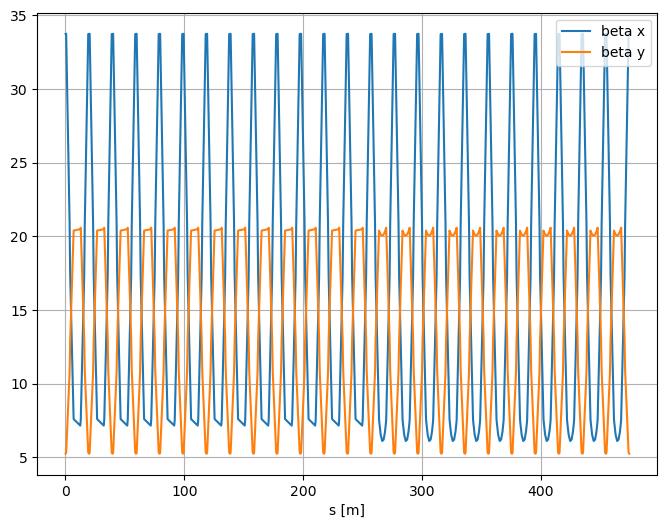

In [59]:
# Columns in file:
# name s beta_x alpha_x psi_x Dx D'x beta_y alpha_y psi_y

lf = np.loadtxt('lattice_functions.csv', usecols=(1,2,3,4,5,6,7,8,9))
plt.plot(lf[:, 0], lf[:, 1], label='beta x')
plt.plot(lf[:, 0], lf[:, 6], label='beta y')
plt.legend(loc='best')
plt.grid(True)
plt.xlabel('s [m]')

In [2]:
h5 = h5py.File('bpmdata.h5', 'r')
bpmdata = h5.get('mean')[()]
nturns = bpmdata//48

## Get spectrum and tune from all 48 BPMs

In [24]:
N = bpmdata.shape[0] # all the data 48 measurements/turn
# frequency goes 0:47
df = 48.0 * 1.0/N
f = np.arange(N) * df
xt = abs(np.fft.fft(bpmdata[:, 0]))
yt = abs(np.fft.fft(bpmdata[:, 2]))
print('N: ', N)
print('f:', f[:10])
print('f.shape: ', f.shape)
print('xt.shape: ', xt.shape)

N:  48000
f: [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009]
f.shape:  (48000,)
xt.shape:  (48000,)


f.shape:  (48000,)
xt.shape:  (48000,)


Text(0.5, 0, 'frequency')

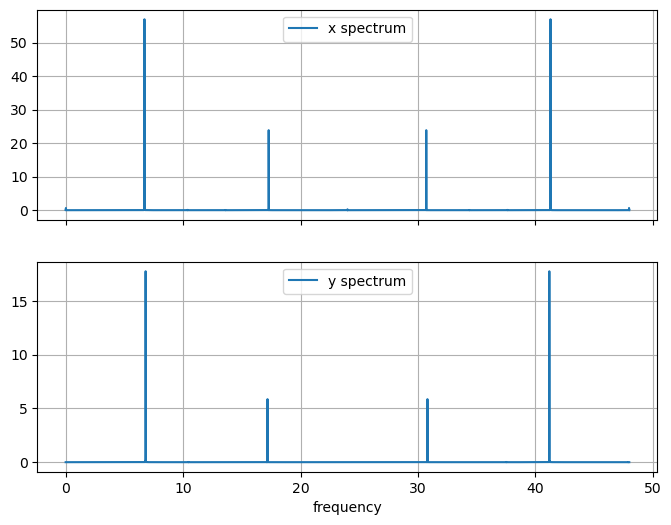

In [25]:
# Plot it
fig,ax = plt.subplots(2, 1, sharex=True)
print('f.shape: ', f.shape)
print('xt.shape: ', xt.shape)
ax[0].plot(f, xt, label='x spectrum')
ax[0].grid(True)
ax[0].legend(loc='best')
ax[1].plot(f, yt, label='y spectrum')
ax[1].grid(True)
ax[1].legend(loc='best')
ax[1].set_xlabel('frequency')

Text(0.5, 0, 'frequency')

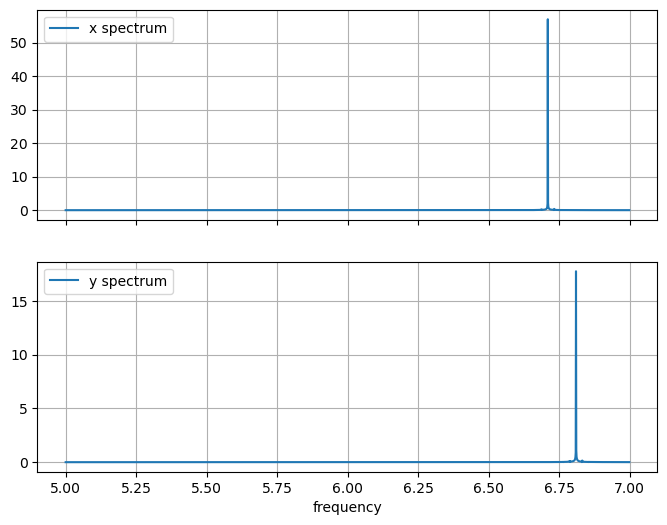

In [26]:
# Plot just 5 to 7 (tunes are about 6.6)
i0 = int(np.floor(5.0/df))
i1 = int(np.ceil(7.0/df))
fig,ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(f[i0:i1], xt[i0:i1], label='x spectrum')
ax[0].grid(True)
ax[0].legend(loc='best')
ax[1].plot(f[i0:i1], yt[i0:i1], label='y spectrum')
ax[1].grid(True)
ax[1].legend(loc='best')
ax[1].set_xlabel('frequency')

Text(0.5, 0, 'frequency')

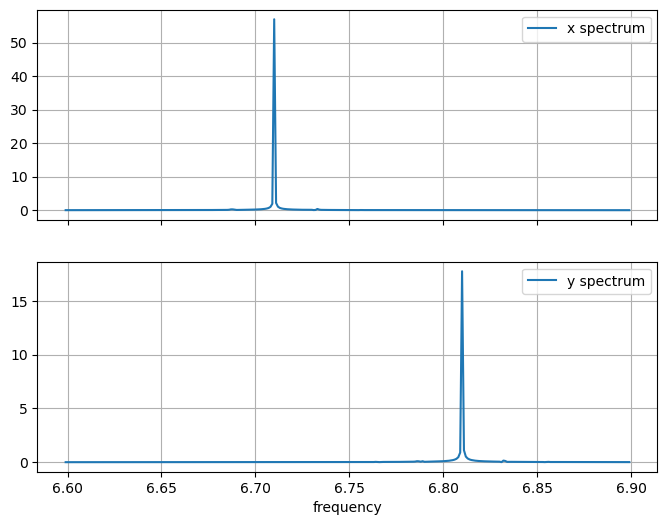

In [31]:
# Plot just 5 to 7 (tunes are about 6.6)
i0 = int(np.floor(6.6/df))
i1 = int(np.ceil(6.9/df))
fig,ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(f[i0:i1], xt[i0:i1], label='x spectrum')
ax[0].grid(True)
ax[0].legend(loc='best')
ax[1].plot(f[i0:i1], yt[i0:i1], label='y spectrum')
ax[1].grid(True)
ax[1].legend(loc='best')
ax[1].set_xlabel('frequency')

Text(0.5, 0, 'frequency')

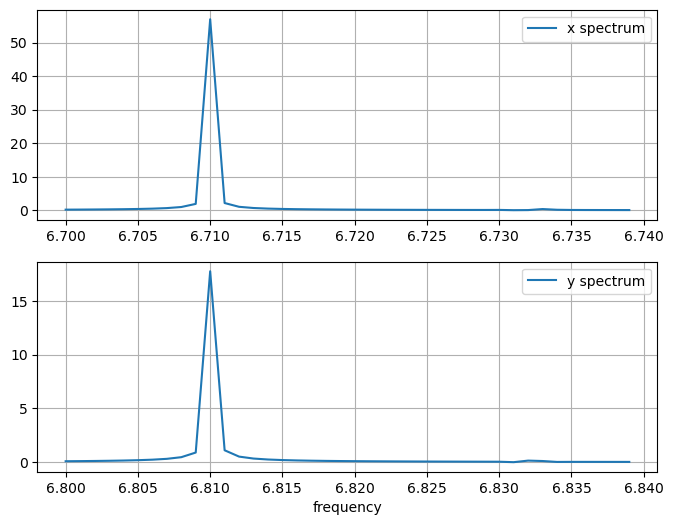

In [40]:
i0 = int(np.floor(6.70/df))
i1 = int(np.ceil(6.74/df))
fig,ax = plt.subplots(2, 1, sharex=False)
ax[0].plot(f[i0:i1], xt[i0:i1], label='x spectrum')
ax[0].grid(True)
ax[0].legend(loc='best')
i2 = int(np.floor(6.80/df))
i3 = int(np.ceil(6.84/df))
ax[1].plot(f[i2:i3], yt[i2:i3], label='y spectrum')
ax[1].grid(True)
ax[1].legend(loc='best')
ax[1].set_xlabel('frequency')

In [6]:
# Separate out short and long BPM data. In the lattice, BPMs occur in the
# sequence short-long-short-long-...
Nbpm_s = bpmdata.shape[0]//48
Nbpm_l = bpmdata.shape[0]//48
bpm_sx = bpmdata[::2, 0]
bpm_sy = bpmdata[::2, 2]
bpm_lx = bpmdata[1::2, 0]
bpm_ly = bpmdata[1::2, 2]
print('NBPM_s: ', Nbpm_s)
print('bpm_sx.shape: ', bpm_sx.shape)

NBPM_s:  1000
bpm_sx.shape:  (24000,)


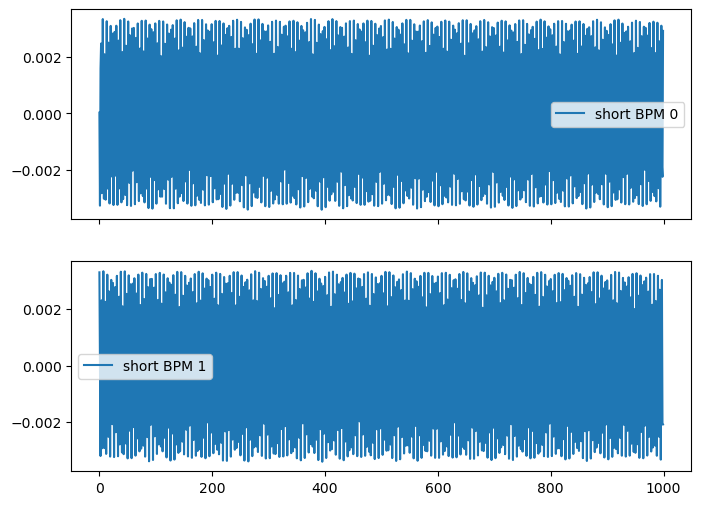

In [7]:
# plot consecutive BPMs to see phase shift (I hope)
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(bpm_sx[0::24], label='short BPM 0')
ax[0].legend(loc='best')
ax[1].plot(bpm_sx[1::24], label='short BPM 1')
ax[1].legend(loc='best')

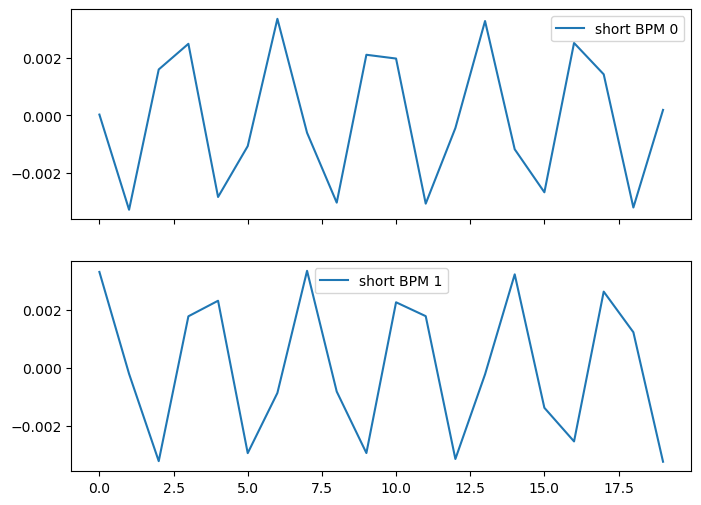

In [8]:
# plot consecutive BPMs to see phase shift (I hope)
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(bpm_sx[0:480:24], label='short BPM 0')
ax[0].legend(loc='best')
ax[1].plot(bpm_sx[1:481:24], label='short BPM 1')
ax[1].legend(loc='best')

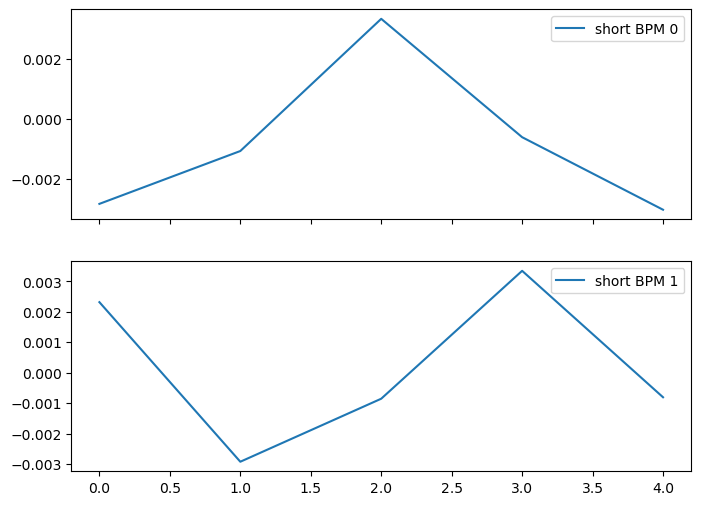

In [58]:
# expand BPM plot
# plot consecutive BPMs to see phase shift (I hope)
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(bpm_sx[0:480:24][4:9], label='short BPM 0')
ax[0].legend(loc='best')
ax[1].plot(bpm_sx[1:481:24][4:9], label='short BPM 1')
ax[1].legend(loc='best')

Number points for single BPM:  1000


Text(0.5, 0, 'fraction of cell')

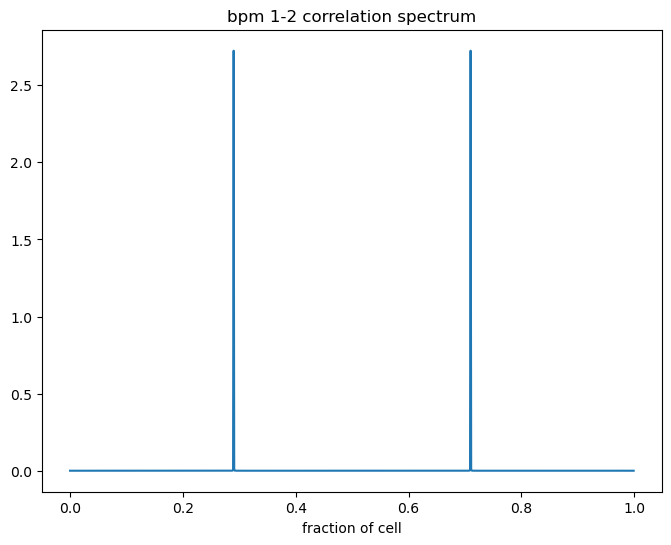

In [51]:
bpm1t = np.fft.fft(bpm_sx[::24])
bpm2t = np.fft.fft(bpm_sx[1::24])
bpmph = abs(bpm2t * bpm1t.conj())
Nc = bpm1t.shape[0] # the number of data points for a single cell
print('Number points for single BPM: ', Nc)
dfc = 1/Nc
fc = np.arange(Nc)*dfc
plt.title('bpm 1-2 correlation spectrum')
plt.plot(fc, bpmph)
plt.xlabel('fraction of cell')


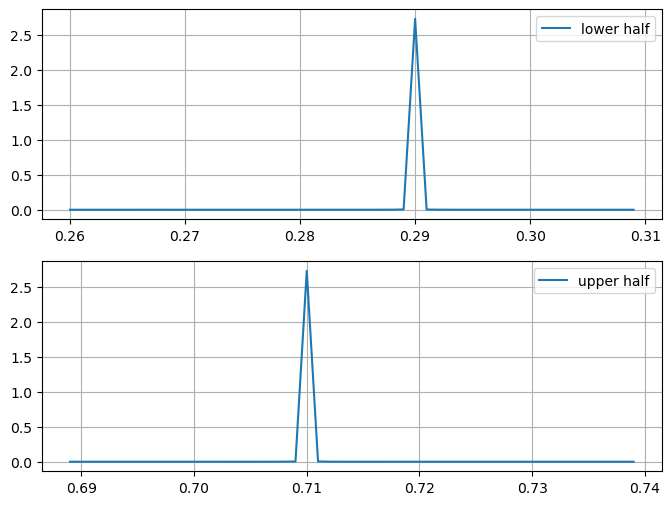

In [52]:
# expand the plot
i0 = int(np.floor(0.26/dfc))
i1 = int(np.ceil(0.31/dfc))
fig,ax = plt.subplots(2, 1, sharex=False)
ax[0].plot(fc[i0:i1], bpmph[i0:i1], label='lower half')
ax[0].grid(True)
ax[0].legend(loc='best')
i2 = int(np.floor((1-0.31)/dfc))
i3 = int(np.ceil((1-0.26)/dfc))
ax[1].plot(fc[i2:i3], bpmph[i2:i3], label='upper half')
ax[1].grid(True)
ax[1].legend(loc='best')



Text(0.5, 0, 'freq')

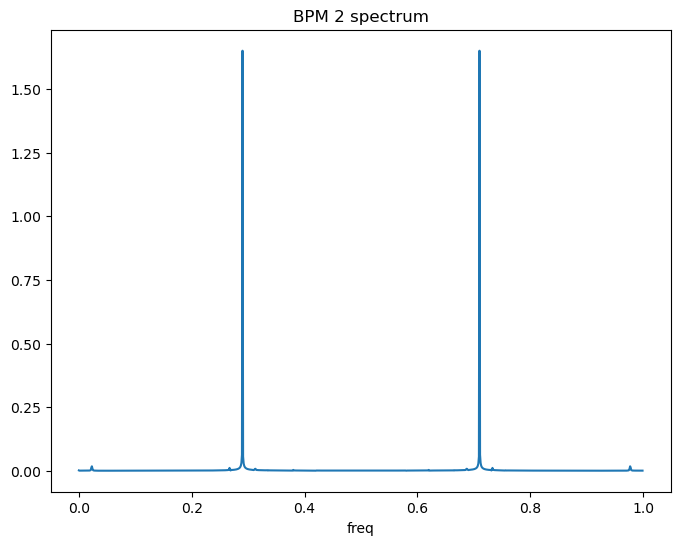

In [54]:
# Look at single bpm spectrum
plt.title('BPM 2 spectrum')
plt.plot(fc, abs(bpm2t))
plt.xlabel('freq')

Not surprisingly looks identical to bpm1-bpm2 difference spectrum